## Задача

Обучить автоэнкодер на MNIST для генерации цифр

Обучаем энкодер + декодер, а затем используем декодер для генерации

## Решение

In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as dataloader
from torchvision import datasets, transforms
from torchvision.utils import save_image
import matplotlib.pyplot as plt
from PIL import Image

In [11]:
# Определение устройства
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(device)

cuda


In [12]:
# Параметры
BATCH_SIZE = 32
LATENT_DIM = 20
NUM_EPOCH = 50

In [13]:
# Преобразования
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [25]:
# Загрузка MNIST
train_dataset = datasets.MNIST(root='C:\\Users\\alesh\\PycharmProjects\\PythonProject\\data', train=True, transform=transform, download=True)
train_loader = dataloader.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [26]:
test_dataset = datasets.MNIST(root='C:\\Users\\alesh\\PycharmProjects\\PythonProject\\data', train=False, transform=transform, download=True)
test_loader = dataloader.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [15]:
class Autoencoder(nn.Module):
    def __init__(self,latent_dim):
        super(Autoencoder, self).__init__() # вызов конструктора родителя
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim), # скрытое представление
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    # прямой проход
    def forward(self, x):
        # Преобразуем изображение в вектор
        x = x.view(-1, 784)

        #кодируем
        encoded = self.encoder(x)

        #декодируем
        decoded = self.decoder(encoded)

        return decoded.view(-1, 1, 28, 28)

    # только кодирование
    def encode(self,x):
        x = x.view(-1, 784)
        return self.encoder(x)

    # только декордирвоние
    def decode(self,z):
        return self.decoder(z).view(-1, 1, 28, 28)

In [16]:
# Создаем модель
model = Autoencoder(LATENT_DIM).to(device)
print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=20, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=512, bias=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=784, bias=True)
    (7): Tanh()
  )
)


In [17]:
# Функция потерь и оптимизатор
criterion = nn.MSELoss() # Среднеквадратичная ошибка
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [18]:
train_losses = []

for epoch in range(NUM_EPOCH):
    model.train()
    total_loss = 0

    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)

        # forward pass
        output = model(data)
        loss = criterion(output, data)

        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch+1)%2 == 0:
        print(f'Epoch {epoch+1}: Loss: {avg_loss:.4f}')

        # Сохраняем примеры реконструкции
        with torch.no_grad():
            # Берем несколько примеров
            sample = data[:2]
            output = model(sample)

            # Сохраняем сравнение оригинал vs реконструкция
            comparison = torch.cat((sample, output))
            save_image(comparison, f'./output/reconstruction_{epoch+1}.png', nrow=8)



Epoch 2: Loss: 0.0723
Epoch 4: Loss: 0.0528
Epoch 6: Loss: 0.0456
Epoch 8: Loss: 0.0414
Epoch 10: Loss: 0.0385
Epoch 12: Loss: 0.0362
Epoch 14: Loss: 0.0346
Epoch 16: Loss: 0.0332
Epoch 18: Loss: 0.0322
Epoch 20: Loss: 0.0313
Epoch 22: Loss: 0.0306
Epoch 24: Loss: 0.0298
Epoch 26: Loss: 0.0292
Epoch 28: Loss: 0.0286
Epoch 30: Loss: 0.0281
Epoch 32: Loss: 0.0277
Epoch 34: Loss: 0.0273
Epoch 36: Loss: 0.0270
Epoch 38: Loss: 0.0266
Epoch 40: Loss: 0.0262
Epoch 42: Loss: 0.0260
Epoch 44: Loss: 0.0258
Epoch 46: Loss: 0.0256
Epoch 48: Loss: 0.0253
Epoch 50: Loss: 0.0252


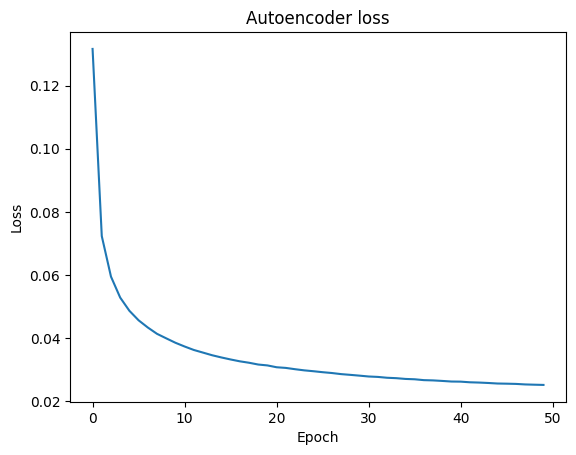

In [19]:
# График потерь
plt.plot(train_losses)
plt.title('Autoencoder loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [27]:
# Реконструкция реальных изображений из тестового набора
def reconstruct_digits(autoencoder, test_loader, num_samples):
    autoencoder.eval() # Переводим в режим инференса

    with torch.no_grad():
        # Берем один батч из тестового загрузчика
        test_data, test_labels = next(iter(test_loader))
        test_data = test_data.to(device)

        # Берем первые num_samples примеров
        real_images = test_data[:num_samples]

        # Получаем скрытые представления
        latent_vectors = autoencoder.encode(real_images)

        # Декодируем скрытые представления
        reconstructed_images = autoencoder.decode(latent_vectors)

        return real_images, reconstructed_images, test_labels[:num_samples]

real_imgs, reconstructed_imgs, labels = reconstruct_digits(model, test_loader, 16)

# Сохраняем сравнение: оригинальные vs реконструированные
comparison = torch.cat([real_imgs, reconstructed_imgs])
save_image(comparison, './output/reconstruction_comparison.png', nrow=8)

print("Реконструкция сохранена в './output/reconstruction_comparison.png'")
print("Метки соответствующих цифр:", labels.numpy())

Реконструкция сохранена в './output/reconstruction_comparison.png'
Метки соответствующих цифр: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5]


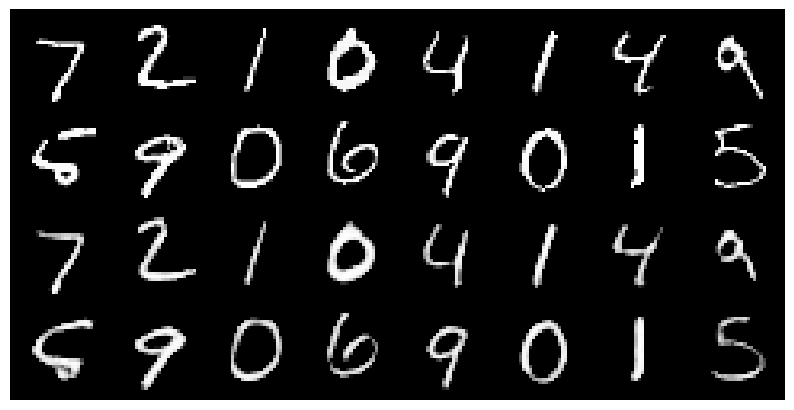

In [51]:
def show_image(image_path):
    img = Image.open(image_path)
    plt.figure(figsize=(10, 10))
    plt.imshow(img) # Отображение изображения
    plt.axis('off')
    plt.show() # Показ окна

show_image('./output/reconstruction_comparison.png')